In [212]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [328]:
def distance_from_closest_value(x, values_taken):
    if not isinstance(x, np.ndarray):
        return min(map(lambda val: abs(val - x), values_taken))
    else:
        return np.array([distance_from_closest_value(xi, values_taken) for xi in  x])


def score(score_function, values_sorted, mode = "user"):
    if mode == "dev":
        return lambda x: score_function(distance_from_closest_value(x, values_sorted))
    elif mode == 'user':
        return lambda x: 1/score_function(distance_from_closest_value(x, values_sorted))
        



In [332]:
def plot_draw(ax, x, f, values_taken):
    ax.set_ylim((0, 10))

    hull = score(f, values_taken, mode = 'dev')
    not_hull = score(f, values_taken, mode = 'user')

    ax.plot(x, hull(x), color='green', ls='-', lw=5)
    ax.plot(x, not_hull(x), color='red', ls='--', lw=2)

/tmp/ipykernel_4129322/1959211304.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


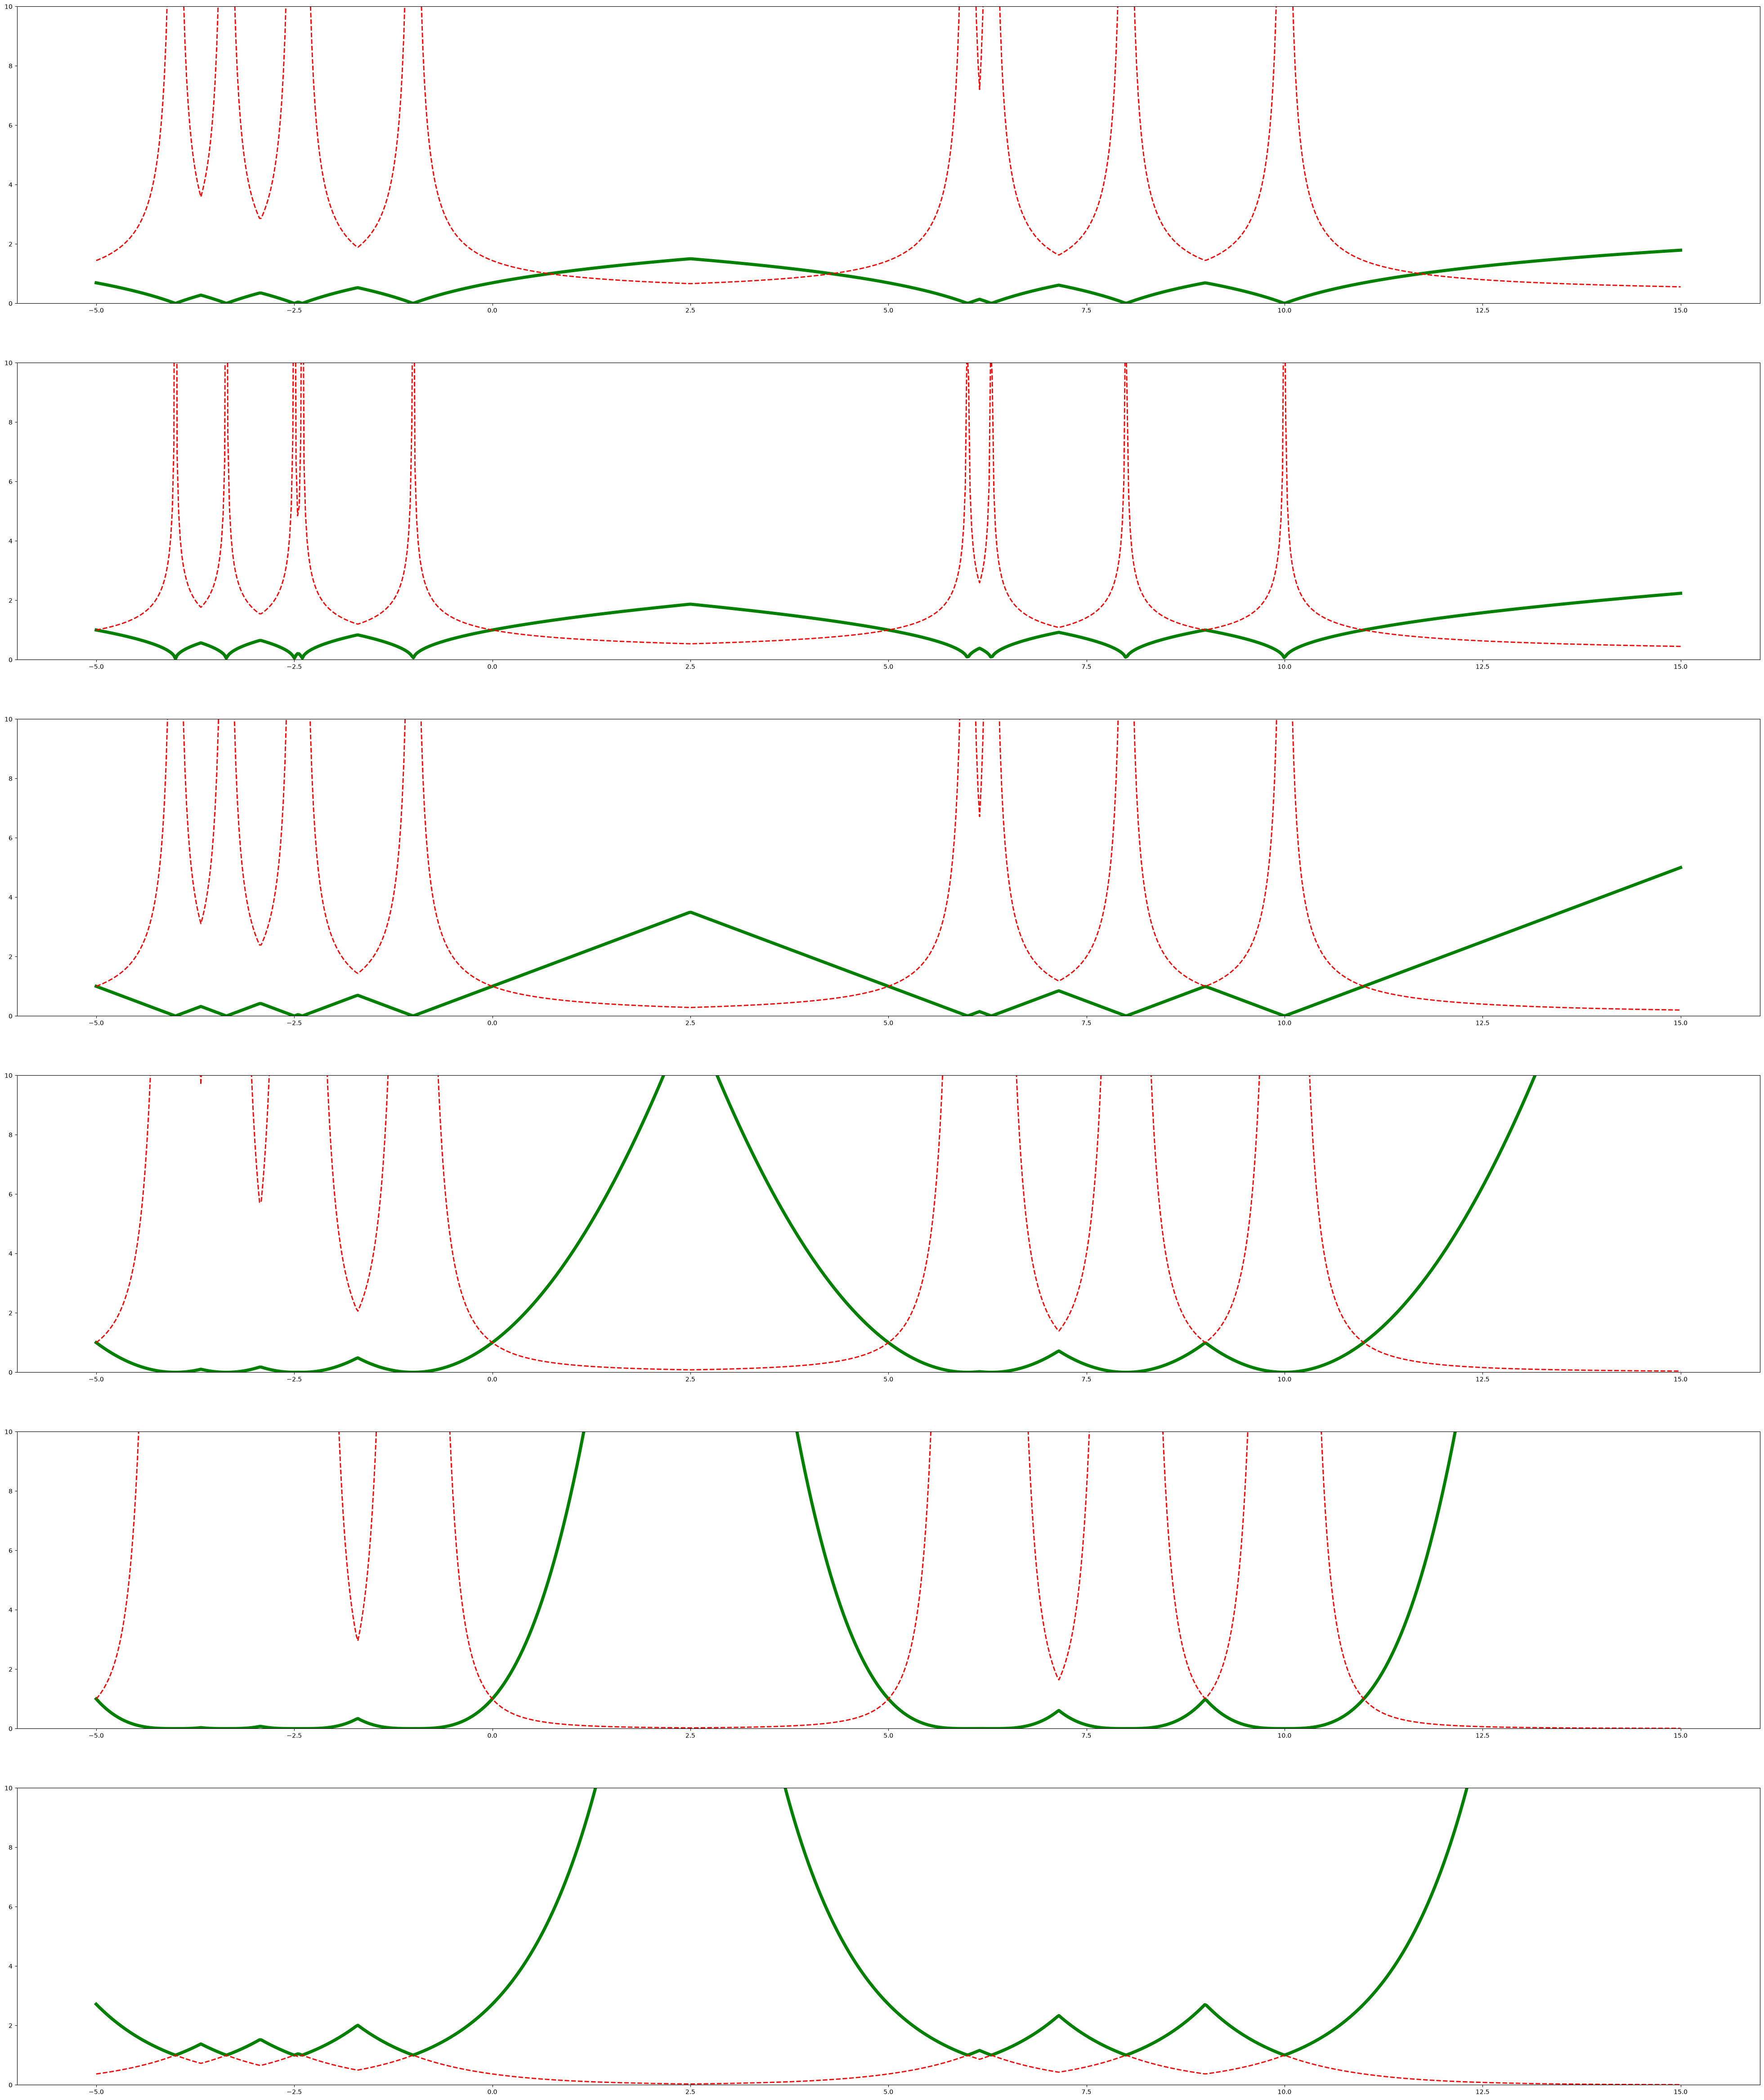

In [334]:
width = 50
height = 10
my_range = (-5, 15)
values_taken = [-4, -3.356, -2.5, -2.4, -1, 6, 6.3, 8, 10]
x = np.linspace(*my_range, 1000)
distance_functions = [lambda x: np.log(x+1), np.sqrt, lambda x: x, lambda x: x**2, lambda x: x**3, np.exp]
subplots = len(distance_functions)

fig, axs = plt.subplots(subplots, 1, figsize=(width, subplots*height))

for i, ax in enumerate(axs):
    plot_draw(ax, x, distance_functions[i], values_taken)

fig.show()

In [265]:
np.array([1, 2, 3, 4, 5])**2

array([ 1,  4,  9, 16, 25])